In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from utils.plots import calculate_accuracy, plot_confusion_matrices, plot_distributions, plot_accuracy, plot_metric_heatmap, plot_precision_recall_curves, plot_cooccurrence, plot_error_distribution, GT_COLS, PRED_COLS, LABELS

0 shot
{'theme_accuracy': np.float64(0.8859813084112149), 'topic_accuracy': np.float64(0.9046728971962616), 'concept_accuracy': np.float64(0.7271028037383177), 'total_accuracy': np.float64(0.5925233644859813)}


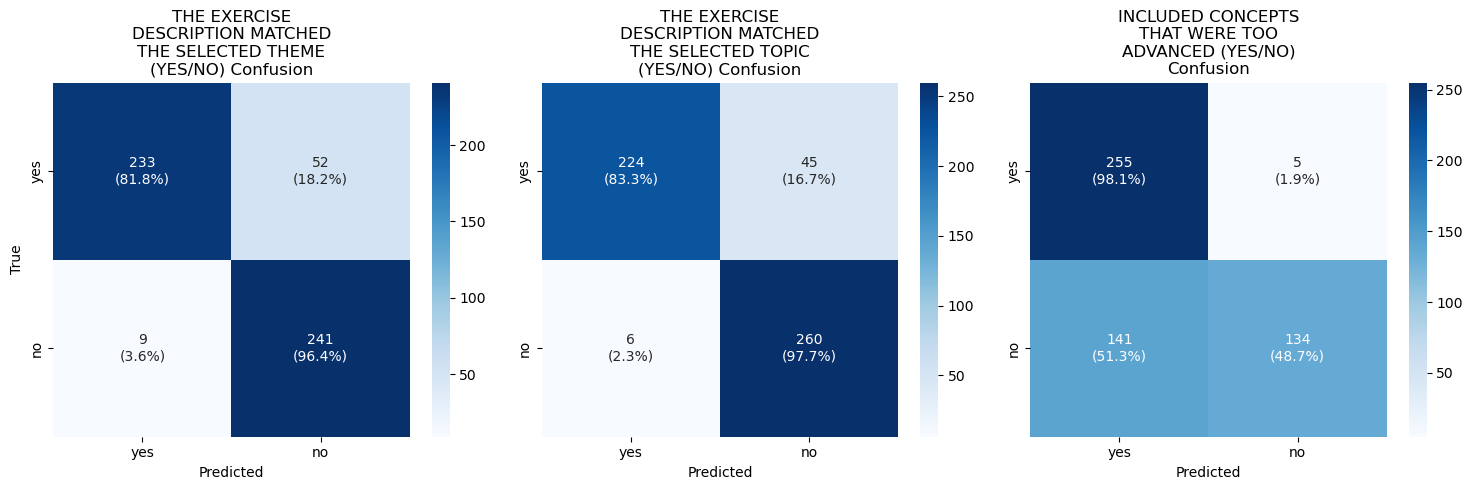

In [24]:
# With concept guardrails in system prompt and list of allowed concepts in user prompt
csvs = [
    ("./outputs/results/batch_16797818_result.csv", "0 shot"),
    #("./outputs/results/batch_16797819_result.csv", "random 1 shot"),
    #("./outputs/results/batch_16797820_result.csv", "random 5 shot"),
    #("./outputs/results/batch_16797821_result.csv", "fixed demos"),
]

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 5 * len(csvs)))
if len(csvs) == 1:
    axes = [axes]

for i, ((path, note), ax) in enumerate(zip(csvs, axes)):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax, use_title=True if i == 0 else False, xlabel="Predicted" if i == (len(csvs) - 1) else "", ylabel="True")
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

0 shot
{'theme_accuracy': np.float64(0.8242990654205608), 'topic_accuracy': np.float64(0.8785046728971962), 'concept_accuracy': np.float64(0.6448598130841121), 'total_accuracy': np.float64(0.5514018691588785)}
random 1 shot
{'theme_accuracy': np.float64(0.822429906542056), 'topic_accuracy': np.float64(0.8429906542056075), 'concept_accuracy': np.float64(0.6523364485981309), 'total_accuracy': np.float64(0.502803738317757)}
random 5 shot
{'theme_accuracy': np.float64(0.9214953271028037), 'topic_accuracy': np.float64(0.9177570093457944), 'concept_accuracy': np.float64(0.6635514018691588), 'total_accuracy': np.float64(0.5757009345794393)}
fixed demos
{'theme_accuracy': np.float64(0.9206049149338374), 'topic_accuracy': np.float64(0.9395085066162571), 'concept_accuracy': np.float64(0.6483931947069943), 'total_accuracy': np.float64(0.5803402646502835)}


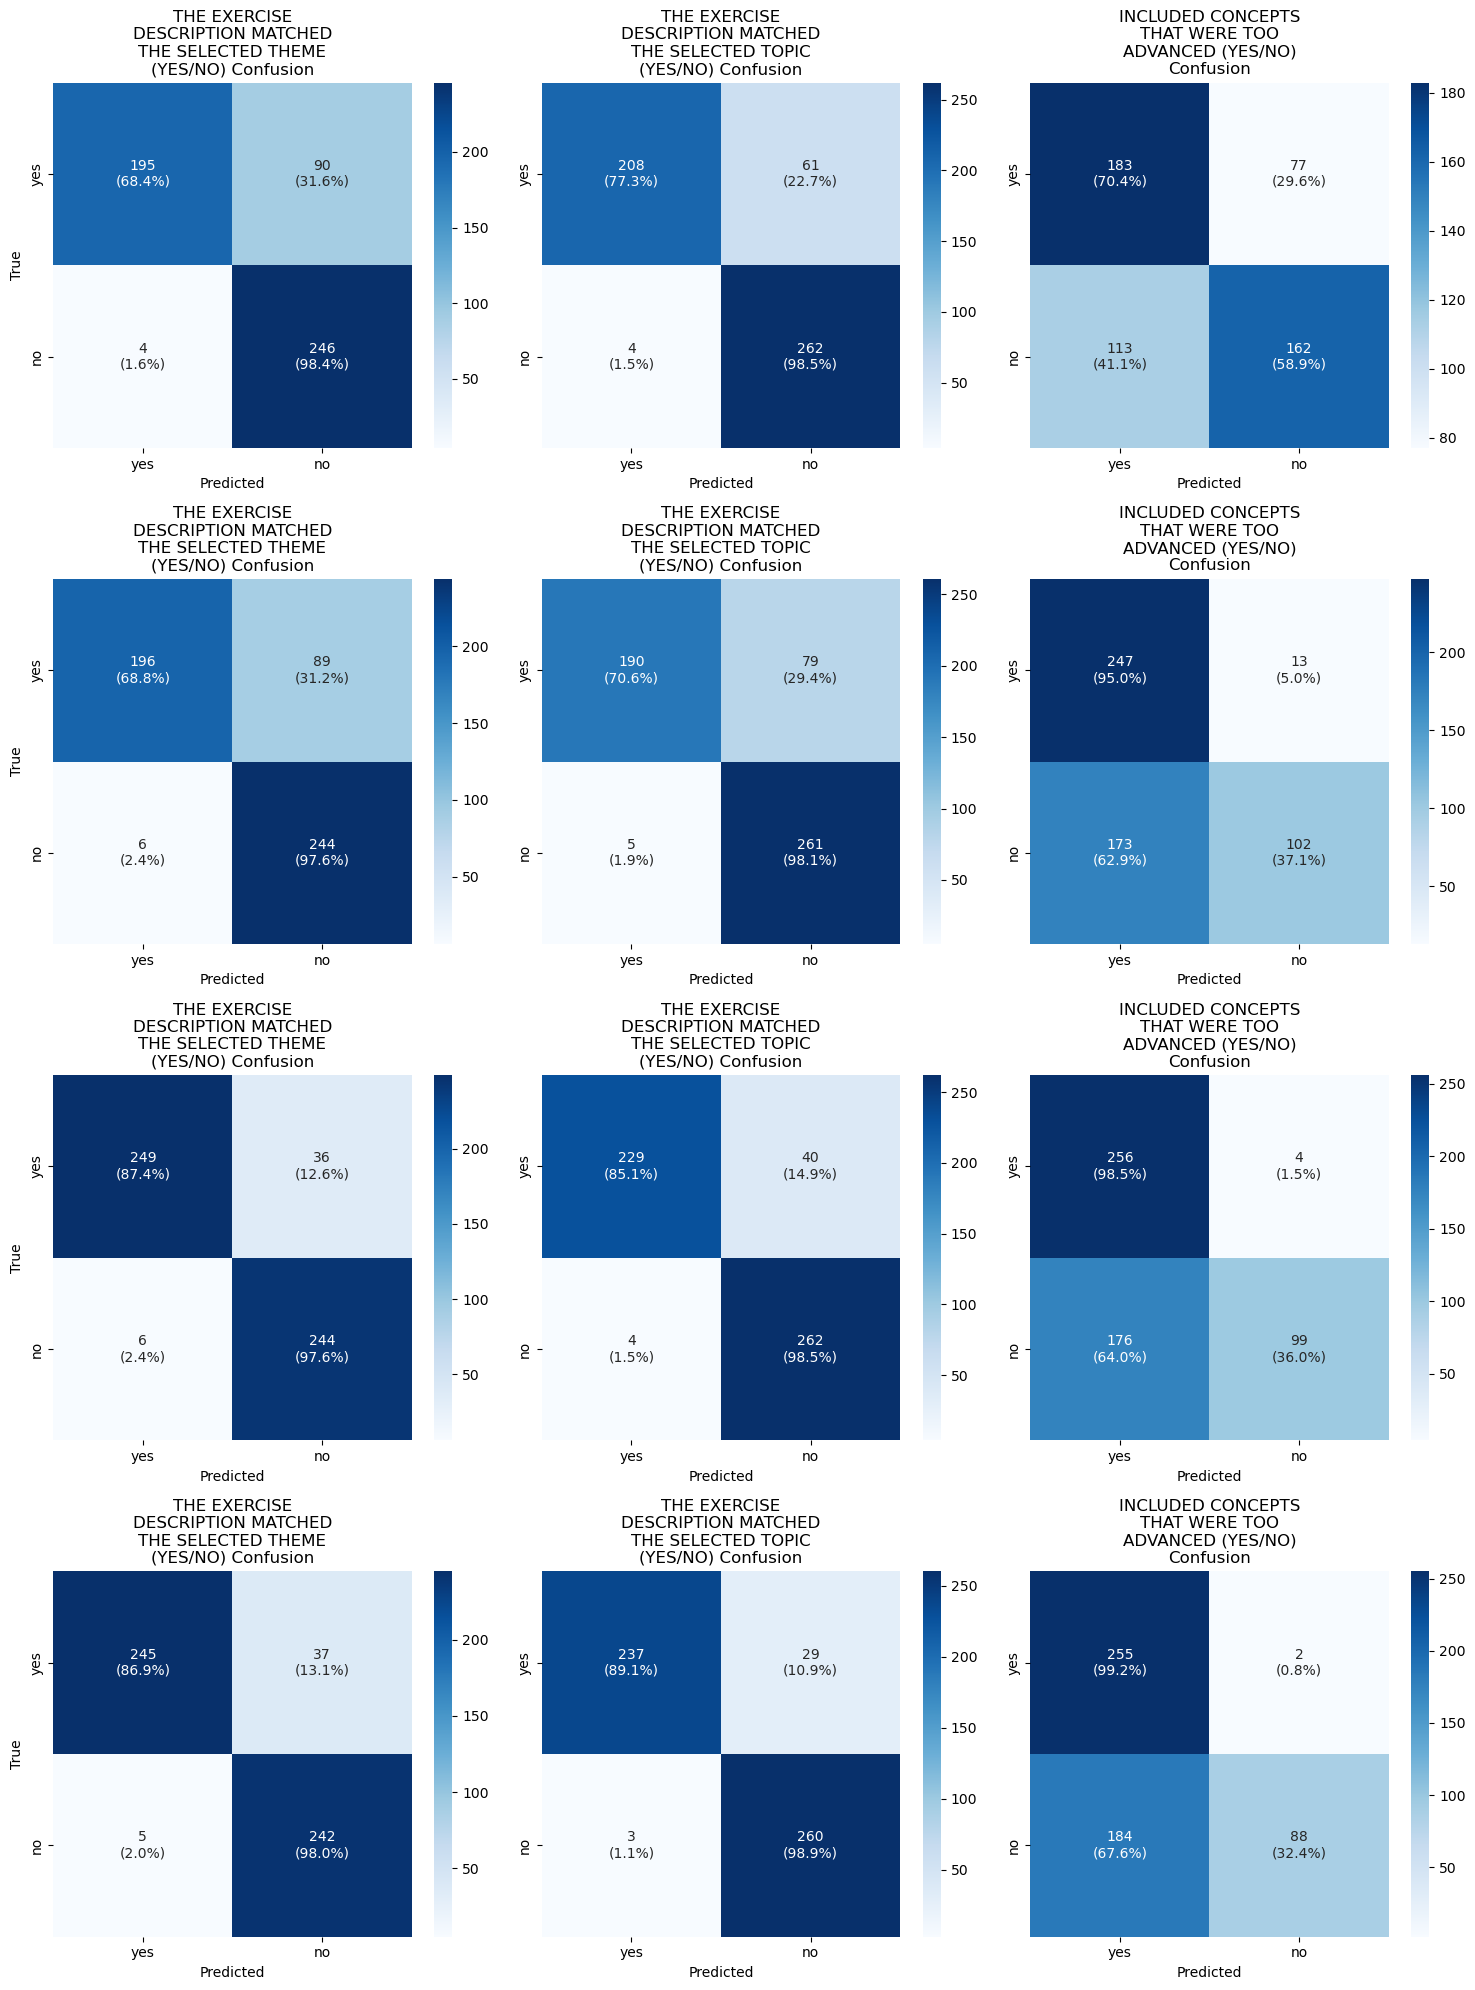

In [6]:
# Without concept guardrails in system prompt and with list of allowed concepts in user prompt
csvs = [
    ("./outputs/results/batch_16817945_result.csv", "0 shot"),
    ("./outputs/results/batch_16817946_result.csv", "random 1 shot"),
    ("./outputs/results/batch_16817947_result.csv", "random 5 shot"),
    ("./outputs/results/batch_16817948_result.csv", "fixed demos"),
]

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 20))

for (path, note), ax in zip(csvs, axes):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax)
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

0 shot
{'theme_accuracy': np.float64(0.9345794392523364), 'topic_accuracy': np.float64(0.9682242990654205), 'concept_accuracy': np.float64(0.8429906542056075), 'total_accuracy': np.float64(0.7906542056074767)}


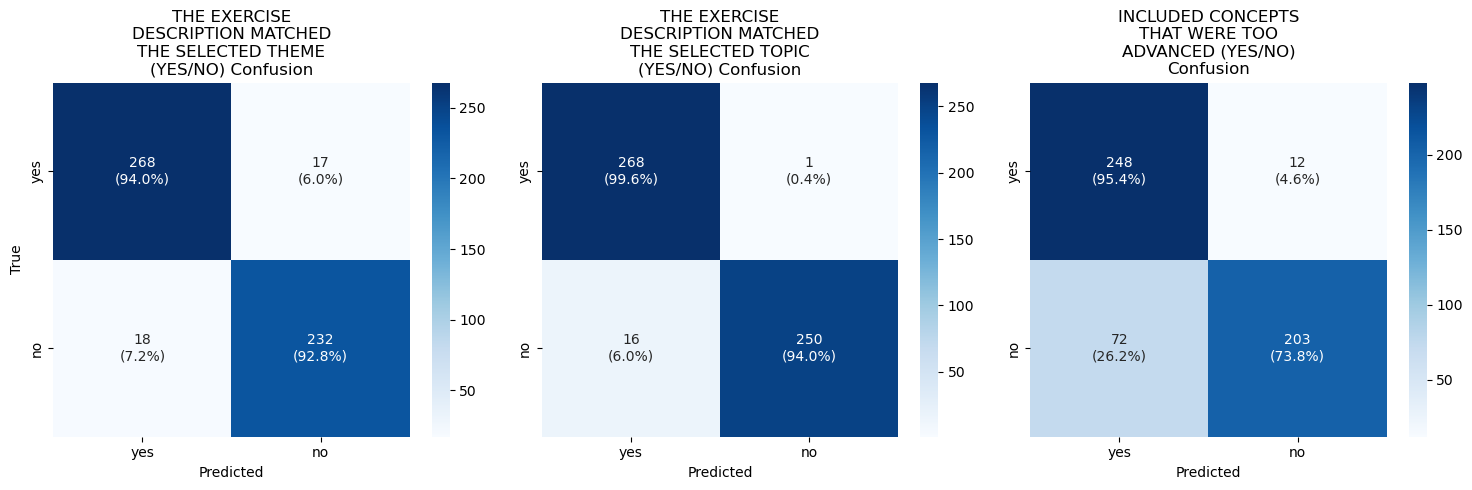

In [25]:
# With concept guardrails in system prompt and list of allowed concepts in user prompt, generated with Qwen-72B
csvs = [
    ("./outputs/results/batch_16824074_result.csv", "0 shot"),
]

fig, axes = plt.subplots(len(csvs), 3, figsize=(15, 5 * len(csvs)))
if len(csvs) == 1:
    axes = [axes]

for i, ((path, note), ax) in enumerate(zip(csvs, axes)):
    print(note)
    df = pd.read_csv(path, sep=";")
    plot_confusion_matrices(df, ax, use_title=True if i == 0 else False, xlabel="Predicted" if i == (len(csvs) - 1) else "", ylabel="True")
    print(calculate_accuracy(df))
    
fig.tight_layout()
plt.show()

In [8]:
def build_figure_for_csv(csvs,
                         labels=LABELS,
                         cols1=GT_COLS,
                         cols2=PRED_COLS,
                         conf=True, acc=True, dist=True):

    filepath, model = csvs
    
    df = pd.read_csv(filepath, sep=";")

    # Layout:
    # Row 0: confusion matrices (3 plots)
    # Row 1: accuracy (1 plot spanning all columns)
    # Row 2-4: distributions (3 rows x 2 columns)

    num_rows = 0
    if conf:
        num_rows += 1
    if acc:
        num_rows += 1
    if dist:
        num_rows += 3

    fig = plt.figure(figsize=(16, num_rows * 6))
    gs = fig.add_gridspec(num_rows, 3)

    # --- Confusion matrices ---
    if conf:
        cm_axes = [
            fig.add_subplot(gs[0, i]) for i in range(3)
        ]
        plot_confusion_matrices(df, cm_axes, labels, cols1, cols2)

    # --- Accuracy (span full width) ---
    if acc:
        acc_ax = fig.add_subplot(gs[1 if conf else 0, :])
        plot_accuracy(df, acc_ax, cols1, cols2)

    # --- Distributions ---
    if dist:
        dist_axes = [
            [fig.add_subplot(gs[num_rows - 3 + i, 0]),
             fig.add_subplot(gs[num_rows - 3 + i, 1])]
            for i in range(len(cols1))
        ]
    
        plot_distributions(df,
                           pd.DataFrame(dist_axes).values,
                           labels,
                           cols1, cols2)

    fig.suptitle(model, fontsize=16)
    fig.tight_layout()

    return fig


def run_on_csvs(csv_paths, conf=True, acc=True, dist=True):
    figs = []

    for path in csv_paths:
        fig = build_figure_for_csv(path, conf=conf, acc=acc, dist=dist)
        figs.append(fig)

    return figs

#run_on_csvs(csvs, acc=False, dist=False)